In [1]:
# ============================================================
# CELL 1 — FIX PYTORCH / SETUPTOOLS COMPATIBILITY
# ============================================================

!pip install -q "setuptools<82"

import sys
import torch
import setuptools

print("=" * 60)
print("ENVIRONMENT")
print("=" * 60)
print("Python     :", sys.version)
print("PyTorch    :", torch.__version__)
print("CUDA       :", torch.cuda.is_available())
print("Setuptools :", setuptools.__version__)

if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

ENVIRONMENT
Python     : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch    : 2.11.0+cu128
CUDA       : True
Setuptools : 80.10.2
GPU        : Tesla T4


In [2]:
# ============================================================
# CELL 2 — CLEAN BASICSR / REAL-ESRGAN INSTALL
# ============================================================

# Remove failed installations
!pip uninstall -y basicsr realesrgan facexlib gfpgan -q

# Make sure PyTorch's setuptools requirement is respected
!pip install -q "setuptools<82"

# Clone the repositories
%cd /content

!rm -rf /content/BasicSR
!rm -rf /content/Real-ESRGAN

!git clone -q https://github.com/XPixelGroup/BasicSR.git /content/BasicSR
!git clone -q https://github.com/xinntao/Real-ESRGAN.git /content/Real-ESRGAN

# Add both repositories directly to Python's path
import sys

sys.path.insert(0, "/content/BasicSR")
sys.path.insert(0, "/content/Real-ESRGAN")

print("=" * 60)
print("SOURCE REPOSITORIES READY")
print("=" * 60)
print("BasicSR     : /content/BasicSR")
print("Real-ESRGAN : /content/Real-ESRGAN")

/content
SOURCE REPOSITORIES READY
BasicSR     : /content/BasicSR
Real-ESRGAN : /content/Real-ESRGAN


In [ ]:
# ============================================================
# CELL 3 — CREATE PYTHON 3.11 ENVIRONMENT
# ============================================================

!apt-get update -qq
!apt-get install -y -qq python3.11 python3.11-venv python3.11-dev

# Create virtual environment
!rm -rf /content/realesrgan_env
!python3.11 -m venv /content/realesrgan_env

# Upgrade basic packaging tools
!/content/realesrgan_env/bin/python -m pip install -q --upgrade pip
!/content/realesrgan_env/bin/python -m pip install -q "setuptools<82" wheel cython

print("=" * 60)
print("PYTHON 3.11 ENVIRONMENT CREATED")
print("=" * 60)

!/content/realesrgan_env/bin/python --version

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libpython3.11-minimal:amd64.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../0-libpython3.11-minimal_3.11.15-1+noble1_amd64.deb ...
Unpacking libpython3.11-minimal:amd64 (3.11.15-1+noble1) ...
Selecting previously unselected package python3.11-minimal.
Preparing to unpack .../1-python3.11-minimal_3.11.15-1+noble1_amd64.deb ...
Unpacking python3.11-minimal (3.11.15-1+noble1) ...
Selecting previously unselected package libpython3.11-stdlib:amd64.
Preparing to unpack .../2-libpython3.11-stdlib_3.11.15-1+nobl

In [4]:
# ============================================================
# CELL 4 — INSTALL PYTORCH
# ============================================================

!/content/realesrgan_env/bin/python -m pip install -q \
    torch torchvision \
    --index-url https://download.pytorch.org/whl/cu128

print("✓ PyTorch installation complete")

✓ PyTorch installation complete


In [6]:
# ============================================================
# CELL 5 — TEST PYTORCH
# ============================================================

!/content/realesrgan_env/bin/python -c "import torch; print('PyTorch:', torch.__version__); print('CUDA:', torch.cuda.is_available()); print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')"

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [7]:
# ============================================================
# CELL 6 — INSTALL REAL-ESRGAN STACK
# ============================================================

!/content/realesrgan_env/bin/python -m pip install -q \
    basicsr facexlib gfpgan

!/content/realesrgan_env/bin/pip install -q \
    opencv-python-headless Pillow tqdm

%cd /content/Real-ESRGAN

!/content/realesrgan_env/bin/python -m pip install -q --no-build-isolation .

%cd /content

print("✓ Real-ESRGAN installation attempted")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
/content/Real-ESRGAN
  Preparing metadata (pyproject.toml) ... done
/content
✓ Real-ESRGAN installation attempted


In [8]:
# ============================================================
# CELL 7 — FIX BASICSR / TORCHVISION COMPATIBILITY
# ============================================================

import os

compat_file = (
    "/content/realesrgan_env/lib/python3.11/"
    "site-packages/torchvision/transforms/functional_tensor.py"
)

os.makedirs(os.path.dirname(compat_file), exist_ok=True)

with open(compat_file, "w") as f:
    f.write(
        "from torchvision.transforms.functional import rgb_to_grayscale\n"
    )

print("✓ Compatibility file created")
print(compat_file)

✓ Compatibility file created
/content/realesrgan_env/lib/python3.11/site-packages/torchvision/transforms/functional_tensor.py


In [9]:
# ============================================================
# CELL 8 — TEST BASICSR + REAL-ESRGAN
# ============================================================

import subprocess

cmd = [
    "/content/realesrgan_env/bin/python",
    "-c",
    """
import torch
import basicsr
import realesrgan

print("=" * 60)
print("REAL-ESRGAN TEST")
print("=" * 60)
print("PyTorch    :", torch.__version__)
print("CUDA       :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

print("BasicSR    :", basicsr.__file__)
print("RealESRGAN :", realesrgan.__file__)
print("=" * 60)
"""
]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.stdout:
    print(result.stdout)

if result.returncode != 0:
    print("❌ TEST FAILED")
    print(result.stderr)
else:
    print("✅ REAL-ESRGAN STACK WORKING")

REAL-ESRGAN TEST
PyTorch    : 2.11.0+cu128
CUDA       : True
GPU        : Tesla T4
BasicSR    : /content/realesrgan_env/lib/python3.11/site-packages/basicsr/__init__.py
RealESRGAN : /content/realesrgan_env/lib/python3.11/site-packages/realesrgan/__init__.py

✅ REAL-ESRGAN STACK WORKING


In [11]:
# ============================================================
# CELL 9 — MOUNT DRIVE + CHECK MODEL
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

LPSR_CHECKPOINT = (
    "/content/drive/MyDrive/AI_Training/Models/"
    "LPSR_Retraining/checkpoints/lpsr_retrained_best.pth"
)

import os

print("Checkpoint exists:", os.path.exists(LPSR_CHECKPOINT))
print("Checkpoint:", LPSR_CHECKPOINT)

Mounted at /content/drive
Checkpoint exists: True
Checkpoint: /content/drive/MyDrive/AI_Training/Models/LPSR_Retraining/checkpoints/lpsr_retrained_best.pth


In [24]:
# ============================================================
# CELL 10 — UPLOAD PLATE IMAGE
# ============================================================

from google.colab import files
from PIL import Image
import os

uploaded = files.upload()

INPUT_IMAGE = next(iter(uploaded.keys()))

img = Image.open(INPUT_IMAGE).convert("RGB")

print("Image:", INPUT_IMAGE)
print("Original size:", img.size)

Saving plate_002.jpg to plate_002 (1).jpg
Image: plate_002 (1).jpg
Original size: (65, 23)


Device: cuda
Loading checkpoint...
✓ LPSR checkpoint loaded successfully
Epoch: 59
Best validation loss: 0.04975690930601089

Original image size: (65, 23)
LPSR input tensor: (1, 3, 64, 256)

Running LPSR...
✓ LPSR completed
LPSR output size: (256, 64)
Inference time: 0.006 seconds


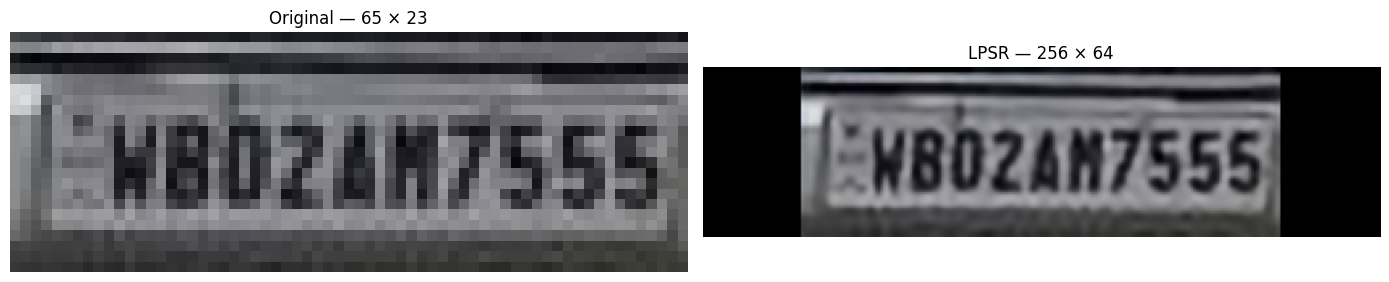

In [26]:
# ============================================================
# CELL 11 — LOAD YOUR ACTUAL TRAINED TRAFFIQ LPSR
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import time

from PIL import Image, ImageOps
import matplotlib.pyplot as plt

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# RDB — EXACT ARCHITECTURE FROM YOUR TRAINING NOTEBOOK
# ============================================================

class RDB(nn.Module):

    def __init__(
        self,
        channels=64,
        growth=32,
        num_layers=4
    ):
        super().__init__()

        self.layers = nn.ModuleList()

        for i in range(num_layers):

            in_channels = channels + i * growth

            self.layers.append(
                nn.Conv2d(
                    in_channels,
                    growth,
                    kernel_size=3,
                    padding=1
                )
            )

        self.local_fusion = nn.Conv2d(
            channels + num_layers * growth,
            channels,
            kernel_size=1
        )

    def forward(self, x):

        features = [x]

        for layer in self.layers:

            inp = torch.cat(
                features,
                dim=1
            )

            out = F.relu(
                layer(inp),
                inplace=True
            )

            features.append(out)

        fused = self.local_fusion(
            torch.cat(features, dim=1)
        )

        return fused + x


# ============================================================
# CHANNEL ATTENTION
# ============================================================

class ChannelAttention(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):
        super().__init__()

        hidden = max(
            channels // reduction,
            4
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden,
                kernel_size=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                hidden,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        attention = self.avg_pool(x)

        attention = self.fc(attention)

        return x * attention


# ============================================================
# SPATIAL ATTENTION
# ============================================================

class SpatialAttention(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=7,
            padding=3
        )

    def forward(self, x):

        avg = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        maximum = torch.max(
            x,
            dim=1,
            keepdim=True
        )[0]

        combined = torch.cat(
            [avg, maximum],
            dim=1
        )

        attention = torch.sigmoid(
            self.conv(combined)
        )

        return x * attention


# ============================================================
# CSAR BLOCK
# ============================================================

class CSARBlock(nn.Module):

    def __init__(
        self,
        channels=64
    ):
        super().__init__()

        self.rdb = RDB(
            channels=channels
        )

        self.channel_attention = ChannelAttention(
            channels
        )

        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        residual = x

        x = self.rdb(x)

        x = self.channel_attention(x)

        x = self.spatial_attention(x)

        return x + residual


# ============================================================
# TRAFFIQ LPSR
# EXACT ARCHITECTURE FROM YOUR NOTEBOOK
# ============================================================

class TraffiqLPSR(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        features=64,
        num_blocks=4
    ):
        super().__init__()

        # Initial feature extraction
        self.head = nn.Conv2d(
            in_channels,
            features,
            kernel_size=3,
            padding=1
        )

        # CSAR feature blocks
        self.blocks = nn.ModuleList([

            CSARBlock(
                channels=features
            )

            for _ in range(num_blocks)

        ])

        # Global feature fusion
        self.global_fusion = nn.Conv2d(
            features * num_blocks,
            features,
            kernel_size=1
        )

        self.global_conv = nn.Conv2d(
            features,
            features,
            kernel_size=3,
            padding=1
        )

        # Reconstruction
        self.reconstruction = nn.Sequential(

            nn.Conv2d(
                features,
                features,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                features,
                out_channels,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        # Global residual
        residual = x

        # Initial features
        x = self.head(x)

        block_outputs = []

        # CSAR blocks
        for block in self.blocks:

            x = block(x)

            block_outputs.append(x)

        # Global feature fusion
        fused = torch.cat(
            block_outputs,
            dim=1
        )

        fused = self.global_fusion(
            fused
        )

        fused = self.global_conv(
            fused
        )

        # Reconstruction
        output = self.reconstruction(
            fused
        )

        # Global residual learning
        output = output + residual

        return output.clamp(
            0,
            1
        )


# ============================================================
# LOAD YOUR TRAINED CHECKPOINT
# ============================================================

LPSR_CHECKPOINT = (
    "/content/drive/MyDrive/AI_Training/Models/"
    "LPSR_Retraining/checkpoints/"
    "lpsr_retrained_best.pth"
)

if not os.path.exists(LPSR_CHECKPOINT):

    raise FileNotFoundError(
        f"LPSR checkpoint not found:\n{LPSR_CHECKPOINT}"
    )

print("Loading checkpoint...")

model = TraffiqLPSR(
    in_channels=3,
    out_channels=3,
    features=64,
    num_blocks=4
).to(DEVICE)


checkpoint = torch.load(
    LPSR_CHECKPOINT,
    map_location=DEVICE
)


# ============================================================
# LOAD WEIGHTS
# ============================================================

if "model_state_dict" in checkpoint:

    state_dict = checkpoint["model_state_dict"]

else:

    state_dict = checkpoint


model.load_state_dict(
    state_dict,
    strict=True
)

model.eval()

print("✓ LPSR checkpoint loaded successfully")

if isinstance(checkpoint, dict):

    print(
        "Epoch:",
        checkpoint.get("epoch", "N/A")
    )

    print(
        "Best validation loss:",
        checkpoint.get(
            "best_val_loss",
            "N/A"
        )
    )


# ============================================================
# PREPARE INPUT IMAGE
# ============================================================

original = Image.open(
    INPUT_IMAGE
).convert("RGB")

print()
print("Original image size:", original.size)


TARGET_W = 256
TARGET_H = 64


# Preserve aspect ratio
contained = ImageOps.contain(
    original,
    (TARGET_W, TARGET_H),
    Image.Resampling.LANCZOS
)


# Black canvas
canvas = Image.new(
    "RGB",
    (TARGET_W, TARGET_H),
    (0, 0, 0)
)


x_offset = (
    TARGET_W - contained.width
) // 2

y_offset = (
    TARGET_H - contained.height
) // 2


canvas.paste(
    contained,
    (x_offset, y_offset)
)


# ============================================================
# IMAGE → TENSOR
# ============================================================

input_array = np.array(
    canvas
).astype(
    np.float32
) / 255.0


input_tensor = torch.from_numpy(
    input_array
).permute(
    2, 0, 1
).unsqueeze(
    0
).to(DEVICE)


print(
    "LPSR input tensor:",
    tuple(input_tensor.shape)
)


# ============================================================
# LPSR INFERENCE
# ============================================================

print()
print("Running LPSR...")

start_time = time.time()

with torch.no_grad():

    lpsr_output = model(
        input_tensor
    )

lpsr_time = (
    time.time() - start_time
)


# ============================================================
# TENSOR → IMAGE
# ============================================================

lpsr_array = (
    lpsr_output[0]
    .detach()
    .cpu()
    .permute(1, 2, 0)
    .numpy()
)


lpsr_array = np.clip(
    lpsr_array * 255.0,
    0,
    255
).astype(
    np.uint8
)


lpsr_pil = Image.fromarray(
    lpsr_array
)


print("✓ LPSR completed")
print("LPSR output size:", lpsr_pil.size)
print(
    "Inference time:",
    round(lpsr_time, 3),
    "seconds"
)


# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.imshow(original)

plt.title(
    f"Original — {original.size[0]} × {original.size[1]}"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(lpsr_pil)

plt.title(
    f"LPSR — {lpsr_pil.size[0]} × {lpsr_pil.size[1]}"
)

plt.axis("off")


plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# CELL 12A — CHECK REAL-ESRGAN WEIGHTS
# ============================================================

import os

MODEL_PATH = "/content/Real-ESRGAN/weights/RealESRGAN_x2plus.pth"

if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    print(f"File exists: {MODEL_PATH}")
    print(f"File size: {size_mb:.2f} MB")
else:
    print("❌ Model file does not exist")

File exists: /content/Real-ESRGAN/weights/RealESRGAN_x2plus.pth
File size: 63.96 MB


In [28]:
# ============================================================
# CELL 12B — DOWNLOAD CORRECT REAL-ESRGAN x2 MODEL
# ============================================================

import os

MODEL_DIR = "/content/Real-ESRGAN/weights"
MODEL_PATH = f"{MODEL_DIR}/RealESRGAN_x2plus.pth"

os.makedirs(MODEL_DIR, exist_ok=True)

# Remove bad/incomplete file
if os.path.exists(MODEL_PATH):
    os.remove(MODEL_PATH)
    print("✓ Removed old/incomplete model")

# Correct official release URL
URL = (
    "https://github.com/xinntao/Real-ESRGAN/"
    "releases/download/v0.2.1/"
    "RealESRGAN_x2plus.pth"
)

print("Downloading Real-ESRGAN x2 model...")
print(URL)
print()

!wget -c "$URL" -O "$MODEL_PATH"

# Check file
if os.path.exists(MODEL_PATH):

    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

    print()
    print(f"Downloaded size: {size_mb:.2f} MB")

    if size_mb > 50:
        print("✓ Real-ESRGAN x2 model downloaded successfully")
    else:
        print("❌ File is still too small/incomplete")

else:

    print("❌ Model download failed")

✓ Removed old/incomplete model
https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.1/RealESRGAN_x2plus.pth

--2026-09-19 04:31:05--  https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.1/RealESRGAN_x2plus.pth
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/387326890/b6ba2c89-c8e5-4fdd-8b79-f906841fcdce?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-19T05%3A04%3A14Z&rscd=attachment%3B+filename%3DRealESRGAN_x2plus.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-19T04%3A04%3A04Z&ske=2026-09-19T05%3A04%3A14Z&sks=b&skv=2018-11-09&sig=aDZq4suu8snX%2FZz4ft%2BFwxcXbjICJYvJAFQ9Lv9ECSU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0

✓ Real-ESRGAN imports successful
Model size: 63.96 MB
✓ Model file valid
Device: cuda
Loading Real-ESRGAN weights...
✓ Real-ESRGAN loaded successfully

LPSR image: (256, 64)
Running Real-ESRGAN x2...

✓ Real-ESRGAN completed
Input size : (256, 64)
Output size: (512, 128)
Inference  : 0.046 seconds


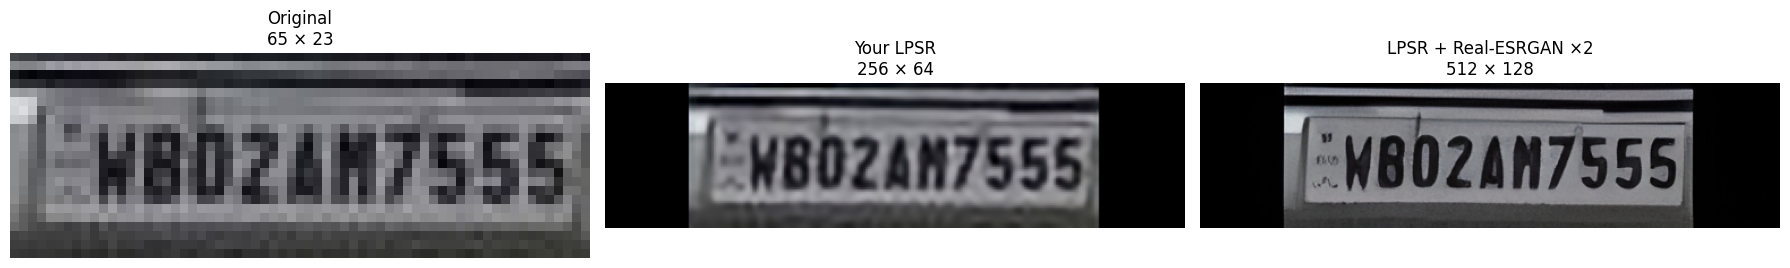

In [29]:
# ============================================================
# CELL 12C — REAL-ESRGAN x2 INFERENCE
# ============================================================

import sys
import os
import torch
import numpy as np
import time

from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

REALESRGAN_ROOT = "/content/Real-ESRGAN"
WEIGHTS = (
    "/content/Real-ESRGAN/weights/"
    "RealESRGAN_x2plus.pth"
)

# Make sure Real-ESRGAN code is available
if REALESRGAN_ROOT not in sys.path:
    sys.path.insert(0, REALESRGAN_ROOT)


# ============================================================
# IMPORTS
# ============================================================

from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet


print("✓ Real-ESRGAN imports successful")


# ============================================================
# CHECK WEIGHTS
# ============================================================

if not os.path.exists(WEIGHTS):
    raise FileNotFoundError(
        f"Model not found:\n{WEIGHTS}"
    )

size_mb = os.path.getsize(WEIGHTS) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

if size_mb < 50:
    raise RuntimeError(
        "Real-ESRGAN weight file appears incomplete."
    )

print("✓ Model file valid")


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# REAL-ESRGAN x2 ARCHITECTURE
# ============================================================

rrdb_model = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=2
)


# ============================================================
# LOAD REAL-ESRGAN
# ============================================================

print("Loading Real-ESRGAN weights...")

upsampler = RealESRGANer(
    scale=2,
    model_path=WEIGHTS,
    model=rrdb_model,
    tile=0,
    tile_pad=10,
    pre_pad=0,
    half=(DEVICE.type == "cuda"),
    device=DEVICE
)

print("✓ Real-ESRGAN loaded successfully")


# ============================================================
# INPUT = LPSR OUTPUT FROM CELL 11
# ============================================================

if "lpsr_pil" not in globals():
    raise RuntimeError(
        "lpsr_pil not found. Run Cell 11 first."
    )

print()
print("LPSR image:", lpsr_pil.size)


# ============================================================
# REAL-ESRGAN INFERENCE
# ============================================================

lpsr_np = np.array(
    lpsr_pil.convert("RGB")
)

print("Running Real-ESRGAN x2...")

start = time.time()

enhanced_np, _ = upsampler.enhance(
    lpsr_np,
    outscale=2
)

elapsed = time.time() - start


# ============================================================
# OUTPUT
# ============================================================

realesrgan_pil = Image.fromarray(
    enhanced_np.astype(np.uint8)
)


print()
print("✓ Real-ESRGAN completed")
print("Input size :", lpsr_pil.size)
print("Output size:", realesrgan_pil.size)
print("Inference  :", round(elapsed, 3), "seconds")


# ============================================================
# DISPLAY
# ============================================================

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)

plt.imshow(original)

plt.title(
    f"Original\n{original.size[0]} × {original.size[1]}"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(lpsr_pil)

plt.title(
    f"Your LPSR\n{lpsr_pil.size[0]} × {lpsr_pil.size[1]}"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(realesrgan_pil)

plt.title(
    f"LPSR + Real-ESRGAN ×2\n"
    f"{realesrgan_pil.size[0]} × {realesrgan_pil.size[1]}"
)

plt.axis("off")

plt.tight_layout()
plt.show()